# Assignment: Exploratory Data Analysis


**Q1.** To compute the sample mean of a variable $X$:
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Instead of the mean, consider the median. Consider transformations that are non-decreasing (if $x\ge x'$, then $g(x)\ge g(x')$), like $2+5 \times X$ or $\text{arcsinh}(X)$. Is a non-decreasing transformation of the median the median of the transformed variable? Explain. Does your answer apply to any quantile? The IQR? The range? 
5. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

[Open Question1.pdf directly](./Question1.pdf)

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. What are the top 15 institutions in terms of the total amount of money they receive? Make a histogram of the total amount received by all institutions. 
7. Which giftors provide the most money, in total?


---------------- Part 1+2 ---------------



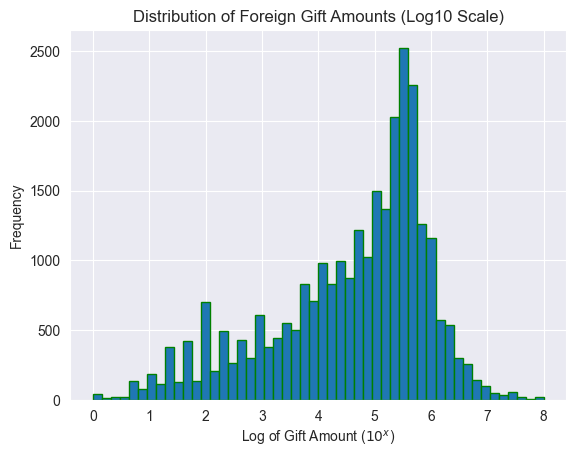


---------------- Part 3 ---------------

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Contract: 0.6120973742957372 Estate: 0.00038978065979235324 Gift: 0.3875128450444704

---------------- Part 4 ---------------



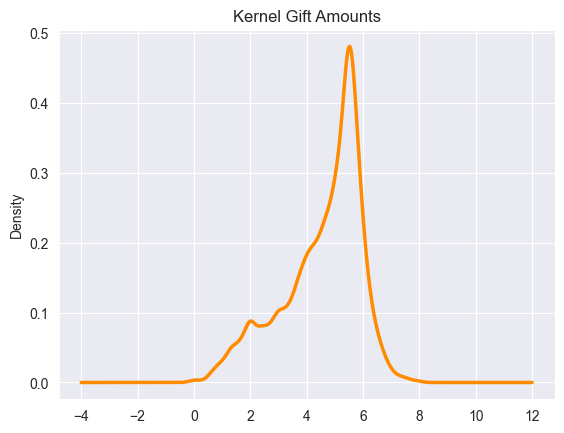

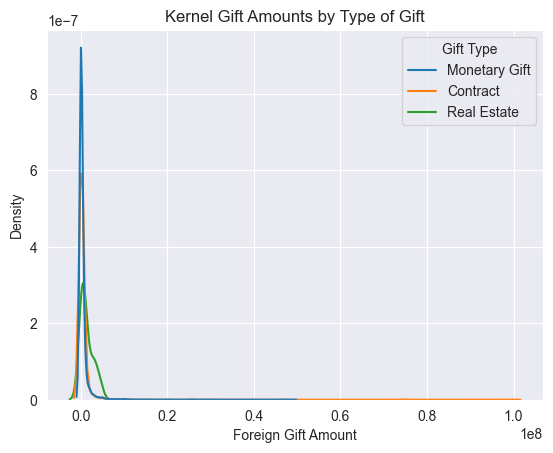


---------------- Part 5 ---------------

Top 15 Countries (Number of Gifts):
 Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64

Top 15 Countries (Total Amount):
 Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE

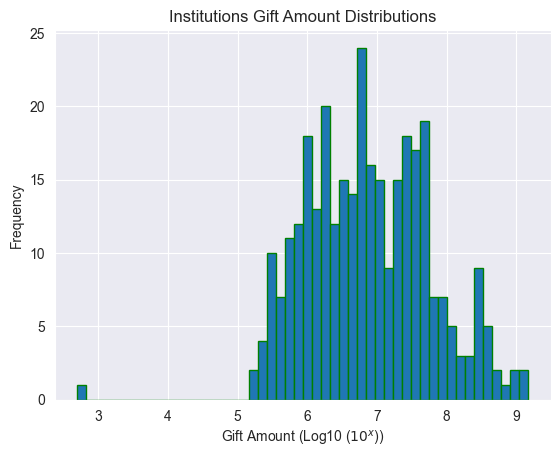


---------------- Part 7 ---------------

Top Giftors (Total Amount):
 Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('./data/ForeignGifts_edu.csv')

## Makes the histogram, had Gemini help me make it not just look like an outlier mess.
print("\n" + "---------------- Part 1+2 ---------------" + "\n")
df['Foreign Gift Amount'] = pd.to_numeric(df['Foreign Gift Amount'], errors="coerce")
clean_df = df[df['Foreign Gift Amount'] > 0].copy()
clean_df['log_amount'] = np.log10(clean_df['Foreign Gift Amount'])
clean_df['log_amount'].hist(bins=50, edgecolor='green')

plt.title('Distribution of Foreign Gift Amounts (Log10 Scale)')
plt.xlabel('Log of Gift Amount ($10^x$)')
plt.ylabel('Frequency')
plt.show()
## It's showing how much they got in foreign gift amounts, with a lot of the gifts being aronud 10k-1M dollars, with a lot of outliers below or above that.
## The major peak is around 250000 dollars, but after a million it cuts off, with a steady incline up to that point from 10 dollars.

print("\n" + "---------------- Part 3 ---------------" + "\n")
print(df['Gift Type'].value_counts())
known = df["Gift Type"]
contract = (known == "Contract").sum()
gift = (known == "Monetary Gift").sum()
estate = (known == "Real Estate").sum()
total = contract + gift + estate
print("Contract:", contract/total, "Estate:", estate/total, "Gift:", gift/total)
# About 61% are contract, with a total of 17k. A very small percent is under estate, only 11. Finally, about 10k, or 38%, are Monetary Gifts.

print("\n" + "---------------- Part 4 ---------------" + "\n")
clean_df["log_amount"].plot(kind='kde', color='darkorange', linewidth=2.5)
plt.title('Kernel Gift Amounts')
plt.show()
sns.kdeplot(data=clean_df, x="Foreign Gift Amount", hue="Gift Type", common_norm=False) # Had assitance from Gemini setting up this line
plt.title('Kernel Gift Amounts by Type of Gift')
plt.show()

print("\n" + "---------------- Part 5 ---------------" + "\n")
top_countries_count = df['Country of Giftor'].value_counts().head(15)
print("Top 15 Countries (Number of Gifts):\n", top_countries_count)
top_countries_amount = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print("\nTop 15 Countries (Total Amount):\n", top_countries_amount)

print("\n" + "---------------- Part 6 ---------------" + "\n")
top_institutions = df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print("Top 15 Institutions:\n", top_institutions)
institutions = df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)
np.log10(institutions).hist(bins=50, edgecolor='green')
plt.title('Institutions Gift Amount Distributions')
plt.xlabel('Gift Amount (Log10 ($10^x$))')
plt.ylabel('Frequency')
plt.show()

print("\n" + "---------------- Part 7 ---------------" + "\n")
top_giftors = df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print("Top Giftors (Total Amount):\n", top_giftors)


**Q3.** This question uses the Airbnb data to practice making visualizations.

  1. Load the `./data/airbnb_hw.csv` data with Pandas. This provides a dataset of AirBnB rental properties for New York City.  
  2. What are are the dimensions of the data? How many observations are there? What are the variables included? Use `.head()` to examine the first few rows of data.
  3. Cross tabulate `Room Type` and `Property Type`. What patterns do you see in what kinds of rentals are available? For which kinds of properties are private rooms more common than renting the entire property?
  4. For `Price`, make a histogram, kernel density, box plot, and a statistical description of the variable. Are the data badly scaled? Are there many outliers? Use `log` to transform price into a new variable, `price_log`, and take these steps again.
  5. Make a scatterplot of `price_log` and `Beds`. Describe what you see. Use `.groupby()` to compute a desciption of `Price` conditional on/grouped by the number of beds. Describe any patterns you see in the average price and standard deviation in prices.
  6. Make a scatterplot of `price_log` and `Beds`, but color the graph by `Room Type` and `Property Type`. What patterns do you see? Compute a description of `Price` conditional on `Room Type` and `Property Type`. Which Room Type and Property Type have the highest prices on average? Which have the highest standard deviation? Does the mean or median appear to be a more reliable estimate of central tendency, and explain why?
  7. We've looked a bit at this `price_log` and `Beds` scatterplot. Use seaborn to make a `jointplot` with `kind=hex`. Where are the data actually distributed? How does it affect the way you think about the plots in 5 and 6?


---------------- Part 1+2 ---------------

Dimensions (Rows, Columns): (30478, 13)
    Host Id Host Since                                 Name Neighbourhood   \
0   5162530        NaN      1 Bedroom in Prime Williamsburg       Brooklyn   
1  33134899        NaN      Sunny, Private room in Bushwick       Brooklyn   
2  39608626        NaN                 Sunny Room in Harlem      Manhattan   
3       500  6/26/2008   Gorgeous 1 BR with Private Balcony      Manhattan   
4       500  6/26/2008             Trendy Times Square Loft      Manhattan   
5      1039  7/25/2008   Big Greenpoint 1BD w/ Skyline View       Brooklyn   
6      1783  8/12/2008                         Amazing Also      Manhattan   
7      2078  8/15/2008  Colorful, quiet, & near the subway!       Brooklyn   
8      2339  8/20/2008  East Village Cocoon: 2 Bedroom Flat      Manhattan   
9      2339  8/20/2008   Lovely 2 Bedroom East Village Nest      Manhattan   

  Property Type  Review Scores Rating (bin)        Room T

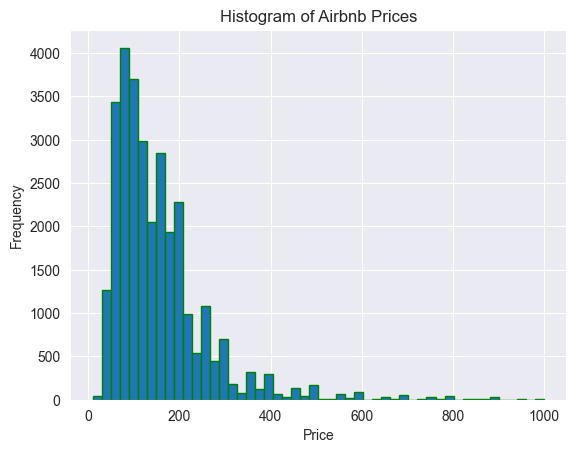

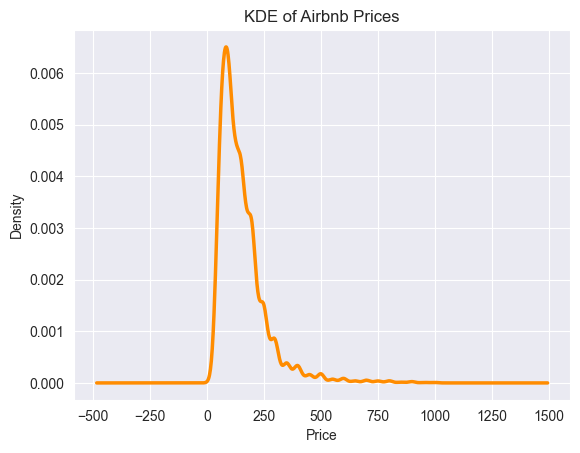

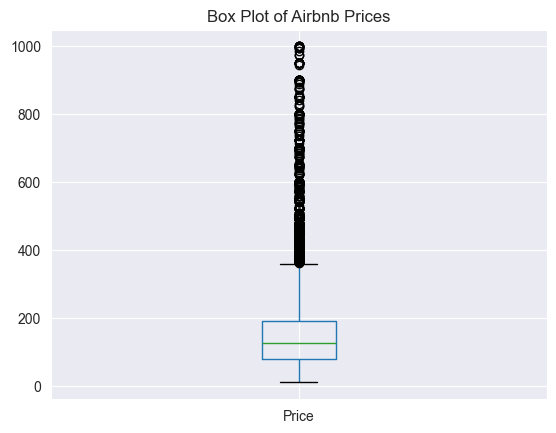


Statistical Description of Price_log:
count    30297.000000
mean         4.854625
std          0.591928
min          2.397895
25%          4.394449
50%          4.836282
75%          5.262690
max          6.907755
Name: price_log, dtype: float64


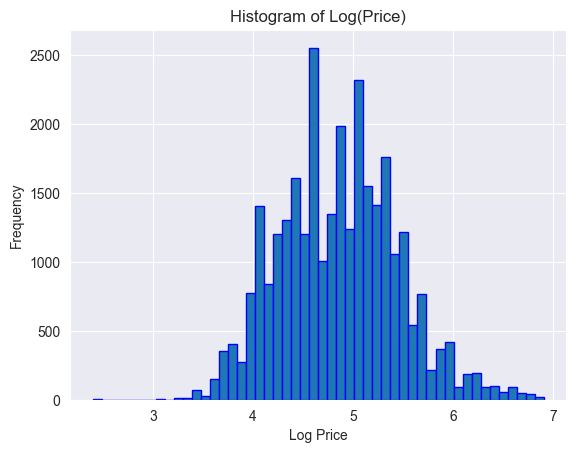

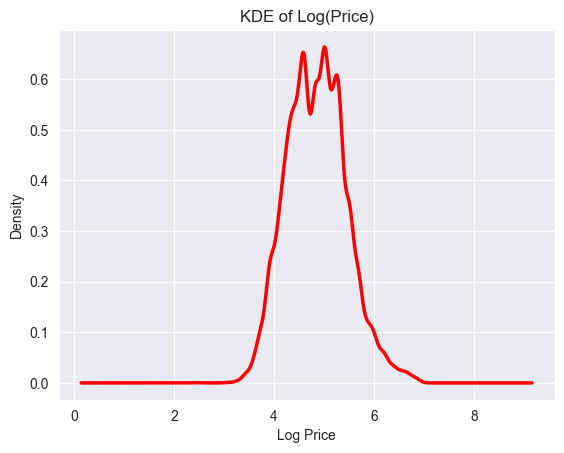

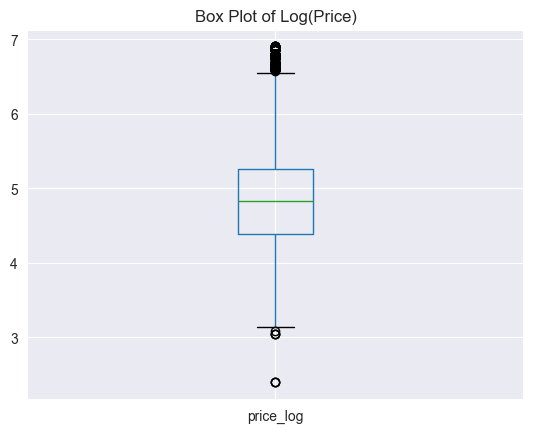


---------------- Part 5 ---------------



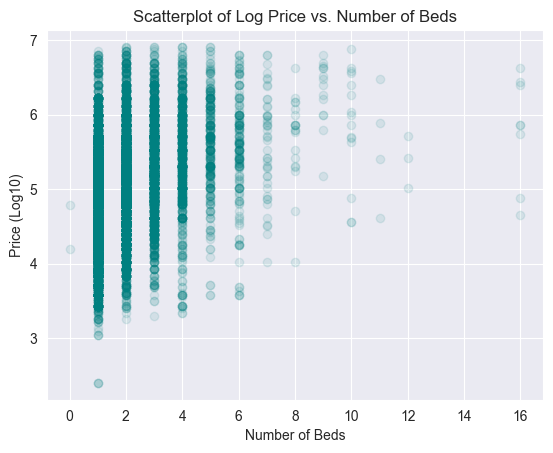

Price Statistics Grouped by Number of Beds:
        count        mean         std    min    50%    max
Beds                                                      
0.0       2.0   92.000000   38.183766   65.0   92.0  119.0
1.0   20307.0  124.757670   75.685752   10.0  100.0  950.0
2.0    6561.0  186.702332  115.044205   25.0  160.0  999.0
3.0    2029.0  234.928043  142.288189   26.0  200.0  999.0
4.0     766.0  280.554830  175.512312   27.0  240.0  999.0
5.0     274.0  322.000000  190.319415   35.0  285.0  995.0
6.0     166.0  316.313253  201.157585   35.0  271.0  900.0
7.0      45.0  341.377778  220.116631   55.0  300.0  900.0
8.0      20.0  331.850000  155.652202   55.0  339.5  750.0
9.0      14.0  587.142857  208.351721  175.0  625.0  900.0
10.0     15.0  442.200000  263.926992   95.0  400.0  975.0
11.0      4.0  332.250000  236.798613  100.0  289.5  650.0
12.0      3.0  225.000000   75.000000  150.0  225.0  300.0
16.0      8.0  402.250000  235.093143  104.0  350.0  750.0

-----------

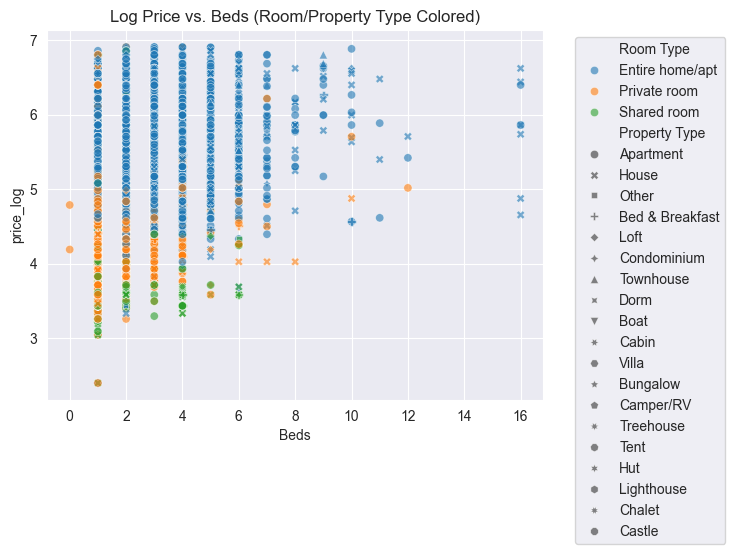

                                   count        mean         std    50%
Room Type       Property Type                                          
Entire home/apt Other               10.0  290.800000  273.526273  177.5
                Loft               379.0  284.910290  184.515517  220.0
                Condominium         71.0  281.126761  175.313998  200.0
                Cabin                1.0  250.000000         NaN  250.0
                Townhouse           81.0  242.037037  166.755243  189.0
                House              723.0  234.554633  159.785974  188.0
                Villa                3.0  206.333333   89.667906  200.0
                Apartment        15550.0  200.210161  109.967435  175.0
                Bed & Breakfast     13.0  184.538462  119.814172  130.0
Private room    Other               28.0  176.642857  141.484252  114.0
Shared room     Treehouse            3.0  167.666667  114.788211  108.0
Entire home/apt Boat                 7.0  158.428571   51.110524

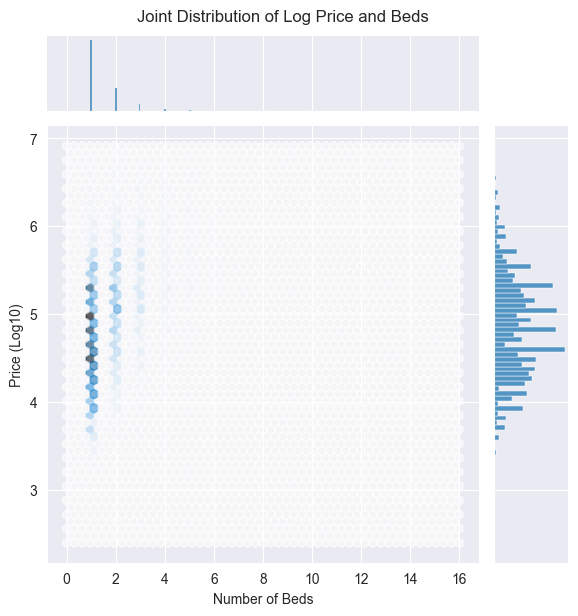

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
## Asked Gemini how to get the Dimensions because I wasn't really sure on a way without printing data.
print("\n" + "---------------- Part 1+2 ---------------" + "\n")
df = pd.read_csv('./data/airbnb_hw.csv')
print("Dimensions (Rows, Columns):", df.shape)
print(df.head(10))
## Includes variables are: Host Id, Host Since, Name, Neightbourhood (misspell?), Property Type, Review Score, Room Type, Zipcode, Beds, Number of Records, Number of Reviews, Price, Review Scores Rating. Some of these values are N/A. 30478 rows and 13 Columns.

print("\n" + "---------------- Part 3 ---------------" + "\n")
ct = pd.crosstab(df['Room Type'], df['Property Type'])
print(ct)
## I see in apartments it's manually entire room or a private room, same thing for Bed and Breakfast except less "Entire home" stuff. Most other entries, such as Castle, Chalet, Cabin, that are less common types of housing, are not shared and instead a private room. The most likely place to have to share a room is in a dorm, where around 11/31 people have a shared room. Also, there are some unique entries with an entire home, such as a Lighthouse.

print("\n" + "---------------- Part 4 ---------------" + "\n")
df['Price'] = pd.to_numeric(df['Price'], errors="coerce")
print("Statistical Description of Price:")
print(df['Price'].describe())
df["Price"].hist(bins=50, edgecolor='green')
plt.title('Histogram of Airbnb Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()
df["Price"].plot(kind='kde', color='darkorange', linewidth=2.5)
plt.title('KDE of Airbnb Prices')
plt.xlabel('Price')
plt.ylabel('Density')
plt.show()
df.boxplot(column='Price')
plt.title('Box Plot of Airbnb Prices')
plt.show()

df['price_log'] = np.log(df['Price'] + 1)
print("\nStatistical Description of Price_log:")
print(df['price_log'].describe())
df["price_log"].hist(bins=50, edgecolor='blue')
plt.title('Histogram of Log(Price)')
plt.xlabel('Log Price')
plt.ylabel('Frequency')
plt.show()
df["price_log"].plot(kind='kde', color='red', linewidth=2.5)
plt.title('KDE of Log(Price)')
plt.xlabel('Log Price')
plt.ylabel('Density')
plt.show()
df.boxplot(column='price_log')
plt.title('Box Plot of Log(Price)')
plt.show()
# Yes, the data was very badly scaled due to a high amount of outliers being in the $100k range or higher, causing the x scale to be messed up.
# With log, this is fixed as these outliers get scaled down to a normal amount.

print("\n" + "---------------- Part 5 ---------------" + "\n")
plt.scatter(df['Beds'], df['price_log'], alpha=0.1, color='teal')
plt.title('Scatterplot of Log Price vs. Number of Beds')
plt.xlabel('Number of Beds')
plt.ylabel('Price (Log10)')
plt.show()
bed_stats = df.groupby('Beds')['Price'].describe()
print("Price Statistics Grouped by Number of Beds:")
print(bed_stats[['count', 'mean', 'std', 'min', '50%', 'max']])
# The price of the room goes up with more beds, until the double digits where it starts to decrease. Standard deviation follows a similar pattern until 8, where it drops off, goes up again, and then goes back and forth up and down.

print("\n" + "---------------- Part 6 ---------------" + "\n")
sns.scatterplot(data=df, x='Beds', y='price_log', hue='Room Type', style='Property Type', alpha=0.6)
plt.title('Log Price vs. Beds (Room/Property Type Colored)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
stats = df.groupby(['Room Type', 'Property Type'])['Price'].describe()
print(stats[['count', 'mean', 'std', '50%']].sort_values(by='mean', ascending=False))
# Entire home is more likely to have more beds, but also a higher price in all of these bed counts. Private room is more common in the lower price ranges on the low bed counts. "Other" and "Loft" had the highest mean price, being around $250 or higher. Standard deviation follows a similar pattern. Median is likely to be more accurate, because outliers and "$100k" rooms could make the data be skewed one way, while the other rooms are not actually that expensive.

print("\n" + "---------------- Part 7 ---------------" + "\n")
g = sns.jointplot(data=df, x='Beds', y='price_log', alpha=0.6, kind="hex")
g.fig.suptitle('Joint Distribution of Log Price and Beds', y=1.02) # Had to ask Gemini how to make a Title for a sns plot.
g.ax_joint.set_xlabel('Number of Beds')
g.ax_joint.set_ylabel('Price (Log10)')
plt.show()
# With the 3 different plots, it really shows how 1 bed is around 4.5 log price, and how deep that really is. It doesn't fully change my understanding as it's very similar data, but it's definitly shows it in a different way!

**Q4.** This question looks at a time series of the number of active oil drilling rigs in the United States over time. The data comes from the Energy Information Agency.

1. Load `./data/drilling_rigs.csv` and examine the data. How many observations? How many variables? Are numeric variables correctly read in by Pandas, or will some variables have to be typecast/coerced? Explain clearly how these data need to be cleaned.
2. To convert the `Month` variable to an ordered datetime variable, use `df['time'] = pd.to_datetime(df['Month'], format='mixed')`.
3. Let's look at `Active Well Service Rig Count (Number of Rigs)`, which is the total number of rigs over time. Make a line plot of this time series. Describe what you see.
4. Instead of levels, we want to look at change over time. Compute the first difference of  `Active Well Service Rig Count (Number of Rigs)` and plot it over time. Describe what you see.
5. The first two columns are the number of onshore and offshore rigs, respectively. Melt these columns and plot the resulting series.


---------------- Part 1+2 ---------------

Dimensions (Rows, Columns): (623, 10)
            Month  \
0    1973 January   
1   1973 February   
2      1973 March   
3      1973 April   
4        1973 May   
5       1973 June   
6       1973 July   
7     1973 August   
8  1973 September   
9    1973 October   

   Crude Oil and Natural Gas Rotary Rigs in Operation, Onshore (Number of Rigs)  \
0                                               1120                              
1                                               1037                              
2                                                959                              
3                                                914                              
4                                                974                              
5                                               1042                              
6                                               1075                              
7                     

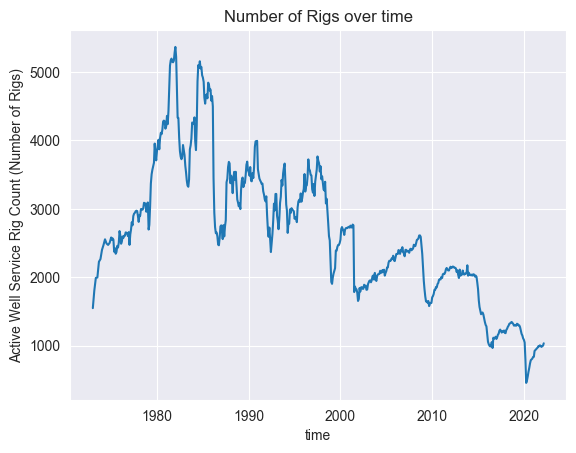


---------------- Part 4 ---------------



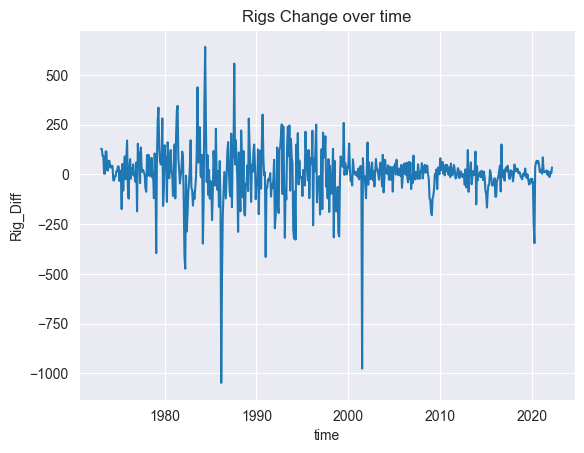


---------------- Part 5 ---------------



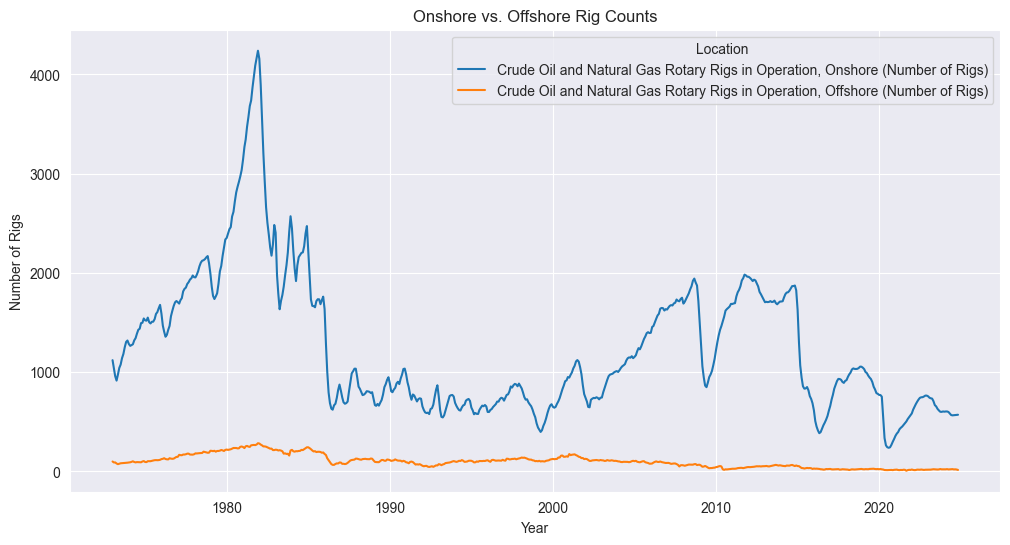

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('./data/drilling_rigs.csv')

print("\n" + "---------------- Part 1+2 ---------------" + "\n")
print("Dimensions (Rows, Columns):", df.shape)
print(df.head(10))
# Everything should be correctly read because there is no dollar signs or any extra figures, it will need to be converted to a number tho.
# Data doesn't really need to be cleaned except converted date and converted numbers.
df['time'] = pd.to_datetime(df['Month'], format='mixed')

print("\n" + "---------------- Part 3 ---------------" + "\n")
df['Active Well Service Rig Count (Number of Rigs)'] = pd.to_numeric(df['Active Well Service Rig Count (Number of Rigs)'], errors="coerce")
sns.lineplot(data=df, x="time",y='Active Well Service Rig Count (Number of Rigs)')
plt.title('Number of Rigs over time')
plt.show()
# I see that it's very jumpy, it peaked around 1981, dropped, peaked, dropped, and kept doing this for a while. Over time, it did slowly decrease, with the number reaching the low hundreds in 2020, and having started at only 1500.

print("\n" + "---------------- Part 4 ---------------" + "\n")
df['Rig_Diff'] = df['Active Well Service Rig Count (Number of Rigs)'].diff()
sns.lineplot(data=df, x="time",y='Rig_Diff')
plt.title('Rigs Change over time')
plt.show()
# I see 2 huge drops, which were the big drops in 1985 as well as around 2002. Overall, The data does hover around the axis, but there are a lot of pretty signifcant drops that cause the number to slowly decrease over time. Tho, there is also some peaks that cause a hike in the number.

print("\n" + "---------------- Part 5 ---------------" + "\n")
# Had Gemini help me with setting up the first step of the melted plot.
df_melted = df.melt(id_vars=['time'], value_vars=['Crude Oil and Natural Gas Rotary Rigs in Operation, Onshore (Number of Rigs)', 'Crude Oil and Natural Gas Rotary Rigs in Operation, Offshore (Number of Rigs)'], var_name='Rig_Location', value_name='Rig_Count')
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_melted, x='time', y='Rig_Count', hue='Rig_Location')
plt.title('Onshore vs. Offshore Rig Counts')
plt.ylabel('Number of Rigs')
plt.xlabel('Year')
plt.legend(title='Location')
plt.show()